In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uttamkantidutta/main-dataset-amazon/collected_product_review_final_dataset (1).xlsx


In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_excel("/kaggle/input/datasets/uttamkantidutta/main-dataset-amazon/collected_product_review_final_dataset (1).xlsx")

In [6]:
df

,Product_ID,Product_Title,Review_Text,Rating,Product_Category,Review_Month,Helpful_Votes,Verified_Purchase,Product_Price_USD,Sentiment
0,B07T6XMZQZ,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",This is my 3td kindle and I love being able to...,4,Computers,2021-11,0,True,21.99,Positive
1,B0C7KBYGN4,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Build quality is fine and the Windows 11 came ...,2,Computers,2023-01,0,True,649.00,Negative
2,B09G9STJF6,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Would not connect to my computer even with tec...,1,Computers,2023-02,0,True,21.99,Negative
3,B01738GIQG,NiSi 150mm Aluminum Square Filter Holder Speci...,"Like most lenses with bulbous front element, u...",5,Camera & Photo,2022-05,0,True,41.01,Positive
4,B000NK5Z8Y,STK NB-5L Battery For Canon Powershot SD790 El...,Work perfectly.,5,Camera & Photo,2016-01,0,True,13.99,Positive
...,...,...,...,...,...,...,...,...,...,...
199995,B00WSM6W8W,"Koss KSC75 Portable Stereophone Headphones, Si...","The sound was good, but I had to return them. ...",2,Home Audio & Theater,2014-07,0,True,25.32,Negative
199996,B09J2BCP87,"ASUS ROG Strix Scar 15 (2021) Gaming Laptop, 1...",The laptop is great. Plays just about everyth...,4,Computers,2022-04,1,True,2499.99,Positive
199997,B07Q41YB14,Pyle PCA1.5 2x15 Watt Stereo Power Amplifier -...,This amplifier is exactly what I was looking f...,5,All Electronics,2021-01,0,True,28.66,Positive
199998,B00FFVYSMK,Dell Venue 8 32 GB Tablet (Android),My high school son is impressed with everythin...,5,Computers,2014-01,1,True,26.99,Positive


In [7]:
df[["Review_Text","Sentiment"]]

,Review_Text,Sentiment
0,This is my 3td kindle and I love being able to...,Positive
1,Build quality is fine and the Windows 11 came ...,Negative
2,Would not connect to my computer even with tec...,Negative
3,"Like most lenses with bulbous front element, u...",Positive
4,Work perfectly.,Positive
...,...,...
199995,"The sound was good, but I had to return them. ...",Negative
199996,The laptop is great. Plays just about everyth...,Positive
199997,This amplifier is exactly what I was looking f...,Positive
199998,My high school son is impressed with everythin...,Positive


In [8]:
df["Sentiment"].value_counts(normalize = True)*100

Sentiment
Positive    76.160
Negative    17.324
Neutral      6.516
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

Product_ID            0
Product_Title         4
Review_Text          55
Rating                0
Product_Category      0
Review_Month          0
Helpful_Votes         0
Verified_Purchase     0
Product_Price_USD     0
Sentiment             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(24)

In [11]:
df[df["Review_Text"].isnull()].shape

(55, 10)

In [12]:
df[df["Review_Text"].isnull()].index

Index([  4414,   8350,  19420,  22626,  23196,  26017,  37162,  46450,  47827,
        54539,  57402,  63694,  66880,  68272,  78196,  94583,  97135,  97357,
        97577,  99210, 102650, 109889, 110113, 110693, 113547, 114901, 114967,
       116366, 128947, 131960, 132725, 138676, 141823, 142033, 144500, 147831,
       148224, 159952, 160536, 161379, 167093, 167573, 168268, 177637, 177854,
       181893, 182385, 185463, 188742, 190676, 191733, 194342, 197849, 197898,
       199797],
      dtype='int64')

In [13]:
df = df.drop(index= [  4414,   8350,  19420,  22626,  23196,  26017,  37162,  46450,  47827,
        54539,  57402,  63694,  66880,  68272,  78196,  94583,  97135,  97357,
        97577,  99210, 102650, 109889, 110113, 110693, 113547, 114901, 114967,
       116366, 128947, 131960, 132725, 138676, 141823, 142033, 144500, 147831,
       148224, 159952, 160536, 161379, 167093, 167573, 168268, 177637, 177854,
       181893, 182385, 185463, 188742, 190676, 191733, 194342, 197849, 197898,
       199797])

In [14]:
df.isnull().sum()

Product_ID           0
Product_Title        4
Review_Text          0
Rating               0
Product_Category     0
Review_Month         0
Helpful_Votes        0
Verified_Purchase    0
Product_Price_USD    0
Sentiment            0
dtype: int64

In [15]:
df[["Review_Text","Sentiment"]]

,Review_Text,Sentiment
0,This is my 3td kindle and I love being able to...,Positive
1,Build quality is fine and the Windows 11 came ...,Negative
2,Would not connect to my computer even with tec...,Negative
3,"Like most lenses with bulbous front element, u...",Positive
4,Work perfectly.,Positive
...,...,...
199995,"The sound was good, but I had to return them. ...",Negative
199996,The laptop is great. Plays just about everyth...,Positive
199997,This amplifier is exactly what I was looking f...,Positive
199998,My high school son is impressed with everythin...,Positive


In [16]:
(df["Review_Text"].astype(str).str.strip() == "").sum()

np.int64(0)

In [17]:
df["Review_Text"].sample(10).tolist()

['Very good product, fast performance when programing, my only request is that the user manual should be improved.',
 'Opened and tried to use on vacation and one set purchased was good.  Not great, but good.  The other, only one worked.  When we got back home, the one month return window was closed.  No returns.  But they look cool.',
 'Works perfectly on my Asus G15 (ryzen 4800hs and nvidia GTX 2060). Total 40GB (8GB onboard + 32GB from this stick). Works like a charm, system recognized as 3200mhz',
 'I love this bag for traveling. Lots of room and looks very expensive.',
 'The remote is advertised as universal, when it arrived there was no way to pair it with my existing Roku device.',
 'Nice product but if you own a newer car, have satellite radio or iPhone or Android integration this becomes redundant.',
 'This is a very good item especially at this price point .',
 "The cable is long, and the connection is tight, but I don't get a fast charge like others are saying. Also, since s

In [18]:
!pip install langdetect

In [19]:
#Language Detection

from langdetect import detect, LangDetectException

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

sample_lang = df["Review_Text"].sample(5000, random_state=42).apply(detect_language)

sample_lang.value_counts()

Review_Text
en    4657
es      53
af      51
ro      42
so      33
ca      23
de      15
da      15
sl      15
fr      13
no      10
pt       9
it       8
nl       7
hu       6
tl       6
sk       4
sv       4
cs       4
id       4
tr       4
cy       4
et       3
vi       3
pl       2
sq       2
hr       1
lt       1
sw       1
Name: count, dtype: int64

In [20]:
df["Review_Text"].str.contains(r"<[^>]+>", regex=True, na=False).sum()

np.int64(24636)

In [21]:
#HTML tags Removal
import re

df["Clean_Text"] = df["Review_Text"].apply(lambda x: re.sub(r"<[^>]+>", " ", str(x)))

df[["Review_Text", "Clean_Text"]].sample(5, random_state=42)

,Review_Text,Clean_Text
196348,"Perfect! And it’s so nice looking, my son was ...","Perfect! And it’s so nice looking, my son was ..."
100683,It’s working and that’s all i asked for,It’s working and that’s all i asked for
155161,It has crazy background noise and barely picks...,It has crazy background noise and barely picks...
193238,"I really like this case, I got the pink and wh...","I really like this case, I got the pink and wh..."
108376,Fits great however it does not glow.,Fits great however it does not glow.


In [22]:
df[df["Review_Text"].str.contains(r"<[^>]+>", regex=True, na=False)][["Review_Text","Clean_Text"]].sample(2)

,Review_Text,Clean_Text
156017,For playing music these earbuds are wonderful ...,For playing music these earbuds are wonderful ...
192574,got this to solve an issue of running cables f...,got this to solve an issue of running cables f...


In [23]:
#REmoving HTML entities

from html import unescape

df["Clean_Text"] = df["Clean_Text"].apply(unescape)

In [24]:
#Normalize the white spaces

df["Clean_Text"] = (df["Clean_Text"].str.replace(r"\s+"," ",regex = True).str.strip())

In [25]:
df["Clean_Text"].sample(5,random_state = 42).tolist()

['Perfect! And it’s so nice looking, my son was over the moon 😉',
 'It’s working and that’s all i asked for',
 'It has crazy background noise and barely picks up my voice. All though I guess for its price it makes sense.',
 "I really like this case, I got the pink and white one. I love Otterbox cases had a grey and white commuter case for my 5c and it fit perfectly. I just recently upgraded my phone to the 6s and this case also has a good fit but it's not perfect as everyone has been saying in the reviews. On my case the gap is only wide enough to fit a finger nail, nothing to big. Also the pink is a lot brighter then the picture provided, it's more of a hot pink, which I like better anyways. I think with time the case will settle and fit better.",
 'Fits great however it does not glow.']

In [26]:
#lowercasing
df["Clean_Text"] = df["Clean_Text"].str.lower()

In [27]:
df["Clean_Text"].sample(5, random_state=42).tolist()

['perfect! and it’s so nice looking, my son was over the moon 😉',
 'it’s working and that’s all i asked for',
 'it has crazy background noise and barely picks up my voice. all though i guess for its price it makes sense.',
 "i really like this case, i got the pink and white one. i love otterbox cases had a grey and white commuter case for my 5c and it fit perfectly. i just recently upgraded my phone to the 6s and this case also has a good fit but it's not perfect as everyone has been saying in the reviews. on my case the gap is only wide enough to fit a finger nail, nothing to big. also the pink is a lot brighter then the picture provided, it's more of a hot pink, which i like better anyways. i think with time the case will settle and fit better.",
 'fits great however it does not glow.']

In [28]:
#contractions and negation word
negation_words = [
    "not", "no", "never",
    "isn't", "wasn't", "aren't", "weren't",
    "don't", "doesn't", "didn't",
    "can't", "couldn't",
    "won't", "wouldn't",
    "shouldn't"
]

negation_counts = {
    word: df["Clean_Text"].str.count(rf"\b{word}\b").sum()
    for word in negation_words
}

negation_counts

{'not': np.int64(68957),
 'no': np.int64(27549),
 'never': np.int64(6449),
 "isn't": np.int64(2780),
 "wasn't": np.int64(2221),
 "aren't": np.int64(970),
 "weren't": np.int64(297),
 "don't": np.int64(13091),
 "doesn't": np.int64(7522),
 "didn't": np.int64(7061),
 "can't": np.int64(6291),
 "couldn't": np.int64(2164),
 "won't": np.int64(3087),
 "wouldn't": np.int64(2081),
 "shouldn't": np.int64(324)}

In [29]:
contractions = {
    "isn't": "is not",
    "wasn't": "was not",
    "aren't": "are not",
    "weren't": "were not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not"
}

for contraction, expansion in contractions.items():
    df["Clean_Text"] = df["Clean_Text"].str.replace(
        rf"\b{contraction}\b",
        expansion,
        regex=True
    )

In [30]:
df["Clean_Text"].sample(10, random_state=42).tolist()

['perfect! and it’s so nice looking, my son was over the moon 😉',
 'it’s working and that’s all i asked for',
 'it has crazy background noise and barely picks up my voice. all though i guess for its price it makes sense.',
 "i really like this case, i got the pink and white one. i love otterbox cases had a grey and white commuter case for my 5c and it fit perfectly. i just recently upgraded my phone to the 6s and this case also has a good fit but it's not perfect as everyone has been saying in the reviews. on my case the gap is only wide enough to fit a finger nail, nothing to big. also the pink is a lot brighter then the picture provided, it's more of a hot pink, which i like better anyways. i think with time the case will settle and fit better.",
 'fits great however it does not glow.',
 'i’m happy to have it. convenient',
 'besides not holding its charge for very long, the sound is very tinny. despite the vendor offering a generous gift card for a five star review, i’ll suggest givi

In [31]:
#URL removals
df["Clean_Text"].str.contains(r"(https?://\S+|www\.\S+)",
    regex=True,
    na=False).sum()

/tmp/ipykernel_2601/37424992.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["Clean_Text"].str.contains(r"(https?://\S+|www\.\S+)",


np.int64(179)

In [32]:
df[df["Clean_Text"].str.contains(r"(https?://\S+|www\.\S+)",
    regex=True,
    na=False)]["Clean_Text"].sample(1).tolist()

/tmp/ipykernel_2601/4152853497.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[df["Clean_Text"].str.contains(r"(https?://\S+|www\.\S+)",


["not sure why a previous review states this does not fit quickport. on the contrary it fits leviton quickport just fine, and any keystone for that matter. this makes a professional looking installation when you need to connect you hdmi cables thru wall plates. i used 2 of these adapters in keystone plates to connect hdmi in-wall from the a/v receiver, up behind the wall, and then to a wall-mounted hdtv. (i put a leviton 690-w box behind a surface mounted hdtv with one of these adapters installed in the keystone plate. i needed to use a 90-degree flat hdmi adapter (90 degree left-hand bend) behind the plate since the recessed front panel of the 690-w reduces the rear clearance by approx 1 inch.) here's what i used with this adapter : http://www.amazon.com/gp/product/b0012dmbga/ref=oss_product http://www.amazon.com/gp/product/b002ljnknm/ref=oss_product"]

In [33]:
df["Clean_Text"] = df["Clean_Text"].str.replace(r"(https?://\S+|www\.\S+)",
    " ",
    regex=True)

In [34]:
df["Clean_Text"].str.contains(
    r"(https?://\S+|www\.\S+)",
    regex=True,
    na=False
).sum()

/tmp/ipykernel_2601/3585555186.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["Clean_Text"].str.contains(


np.int64(0)

In [35]:
#check nd remove special char and, punctuations

import string

string.punctuation

punctuation_count = df["Clean_Text"].apply(lambda x: sum(char in string.punctuation for char in str(x)))

punctuation_count.describe()

count    199945.000000
mean          6.448978
std          12.918444
min           0.000000
25%           1.000000
50%           3.000000
75%           7.000000
max         921.000000
Name: Clean_Text, dtype: float64

In [36]:
import string

df["Clean_Text"] = df["Clean_Text"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

In [37]:
df["Clean_Text"].sample(10, random_state=42).tolist()

['perfect and it’s so nice looking my son was over the moon 😉',
 'it’s working and that’s all i asked for',
 'it has crazy background noise and barely picks up my voice all though i guess for its price it makes sense',
 'i really like this case i got the pink and white one i love otterbox cases had a grey and white commuter case for my 5c and it fit perfectly i just recently upgraded my phone to the 6s and this case also has a good fit but its not perfect as everyone has been saying in the reviews on my case the gap is only wide enough to fit a finger nail nothing to big also the pink is a lot brighter then the picture provided its more of a hot pink which i like better anyways i think with time the case will settle and fit better',
 'fits great however it does not glow',
 'i’m happy to have it convenient',
 'besides not holding its charge for very long the sound is very tinny despite the vendor offering a generous gift card for a five star review i’ll suggest giving this item a hard p

In [38]:
df["Clean_Text"].str.contains(r"\d",regex = True, na = False).sum()

np.int64(56524)

In [39]:
df["Clean_Text"] = (
    df["Clean_Text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [40]:
#Tokenization 

from nltk.tokenize import word_tokenize

df["Tokens"] = df["Clean_Text"].apply(word_tokenize)

In [41]:
df[["Clean_Text", "Tokens"]].sample(5, random_state=42)

,Clean_Text,Tokens
196348,perfect and it’s so nice looking my son was ov...,"[perfect, and, it, ’, s, so, nice, looking, my..."
100683,it’s working and that’s all i asked for,"[it, ’, s, working, and, that, ’, s, all, i, a..."
155161,it has crazy background noise and barely picks...,"[it, has, crazy, background, noise, and, barel..."
193238,i really like this case i got the pink and whi...,"[i, really, like, this, case, i, got, the, pin..."
108376,fits great however it does not glow,"[fits, great, however, it, does, not, glow]"


In [42]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopword_count = df["Tokens"].apply(lambda tokens: sum(word in ENGLISH_STOP_WORDS for word in tokens ))

stopword_count.describe()

count    199945.00000
mean         24.14525
std          41.56550
min           0.00000
25%           4.00000
50%          12.00000
75%          28.00000
max        2087.00000
Name: Tokens, dtype: float64

In [43]:
#stopword_removal

stop_words = set(ENGLISH_STOP_WORDS)

negation_words = {
    "not", "no", "never",
    "isn't", "wasn't", "aren't", "weren't",
    "don't", "doesn't", "didn't",
    "can't", "couldn't",
    "won't", "wouldn't", "shouldn't"
}

stop_words = stop_words - negation_words

In [44]:
df["Tokens_NoStop"] = df["Tokens"].apply(lambda tokens: [word for word in tokens if word not in stop_words])

In [45]:
df[["Tokens", "Tokens_NoStop"]].sample(5, random_state=42)

,Tokens,Tokens_NoStop
196348,"[perfect, and, it, ’, s, so, nice, looking, my...","[perfect, ’, s, nice, looking, son, moon, 😉]"
100683,"[it, ’, s, working, and, that, ’, s, all, i, a...","[’, s, working, ’, s, asked]"
155161,"[it, has, crazy, background, noise, and, barel...","[crazy, background, noise, barely, picks, voic..."
193238,"[i, really, like, this, case, i, got, the, pin...","[really, like, case, got, pink, white, love, o..."
108376,"[fits, great, however, it, does, not, glow]","[fits, great, does, not, glow]"


In [46]:
df["Clean_Text"] = df["Clean_Text"].str.replace(
    "’", "'", regex=False
)



In [47]:
df["Clean_Text"] = df["Clean_Text"].str.replace(
    r"\bit's\b", "it is", regex=True
)

In [48]:
df["Clean_Text"] = df["Clean_Text"].str.replace(
    "'", "", regex=False
)

In [49]:
df["Tokens"] = df["Clean_Text"].apply(word_tokenize)

In [50]:
df[["Clean_Text", "Tokens"]].sample(5, random_state=42)

,Clean_Text,Tokens
196348,perfect and it is so nice looking my son was o...,"[perfect, and, it, is, so, nice, looking, my, ..."
100683,it is working and thats all i asked for,"[it, is, working, and, thats, all, i, asked, for]"
155161,it has crazy background noise and barely picks...,"[it, has, crazy, background, noise, and, barel..."
193238,i really like this case i got the pink and whi...,"[i, really, like, this, case, i, got, the, pin..."
108376,fits great however it does not glow,"[fits, great, however, it, does, not, glow]"


In [51]:
df["Tokens_NoStop"] = df["Tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

In [52]:
df[["Tokens", "Tokens_NoStop"]].sample(5, random_state=42)

,Tokens,Tokens_NoStop
196348,"[perfect, and, it, is, so, nice, looking, my, ...","[perfect, nice, looking, son, moon, 😉]"
100683,"[it, is, working, and, thats, all, i, asked, for]","[working, thats, asked]"
155161,"[it, has, crazy, background, noise, and, barel...","[crazy, background, noise, barely, picks, voic..."
193238,"[i, really, like, this, case, i, got, the, pin...","[really, like, case, got, pink, white, love, o..."
108376,"[fits, great, however, it, does, not, glow]","[fits, great, does, not, glow]"


In [53]:
#Stemming nd Lemmatization
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

test_words = ["working", "worked", "works", "running", "better", "batteries"]

[(word, lemmatizer.lemmatize(word)) for word in test_words]

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


[('working', 'working'),
 ('worked', 'worked'),
 ('works', 'work'),
 ('running', 'running'),
 ('better', 'better'),
 ('batteries', 'battery')]

In [54]:
df["Tokens_Lemma"] = df["Tokens_NoStop"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

In [55]:
df[["Tokens_NoStop", "Tokens_Lemma"]].sample(5, random_state=42)

,Tokens_NoStop,Tokens_Lemma
196348,"[perfect, nice, looking, son, moon, 😉]","[perfect, nice, looking, son, moon, 😉]"
100683,"[working, thats, asked]","[working, thats, asked]"
155161,"[crazy, background, noise, barely, picks, voic...","[crazy, background, noise, barely, pick, voice..."
193238,"[really, like, case, got, pink, white, love, o...","[really, like, case, got, pink, white, love, o..."
108376,"[fits, great, does, not, glow]","[fit, great, doe, not, glow]"


In [56]:
#Convert lemmatized tokens back to text

df["Processed_Text"] = df["Tokens_Lemma"].apply(
    lambda tokens : " ".join(tokens)
)

In [57]:
df[["Clean_Text", "Processed_Text"]].sample(5, random_state=42)

,Clean_Text,Processed_Text
196348,perfect and it is so nice looking my son was o...,perfect nice looking son moon 😉
100683,it is working and thats all i asked for,working thats asked
155161,it has crazy background noise and barely picks...,crazy background noise barely pick voice guess...
193238,i really like this case i got the pink and whi...,really like case got pink white love otterbox ...
108376,fits great however it does not glow,fit great doe not glow


In [58]:
(df["Processed_Text"].str.strip() == "").sum()

np.int64(298)

In [59]:
df = df[df["Processed_Text"].str.strip() != ""].copy()

In [60]:
df["Processed_Text"].str.strip().eq("").sum()

np.int64(0)

In [61]:
df.shape

(199647, 15)

In [62]:
df

,Product_ID,Product_Title,Review_Text,Rating,Product_Category,Review_Month,Helpful_Votes,Verified_Purchase,Product_Price_USD,Sentiment,Clean_Text,Tokens,Tokens_NoStop,Tokens_Lemma,Processed_Text
0,B07T6XMZQZ,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",This is my 3td kindle and I love being able to...,4,Computers,2021-11,0,True,21.99,Positive,this is my 3td kindle and i love being able to...,"[this, is, my, 3td, kindle, and, i, love, bein...","[3td, kindle, love, able, books]","[3td, kindle, love, able, book]",3td kindle love able book
1,B0C7KBYGN4,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Build quality is fine and the Windows 11 came ...,2,Computers,2023-01,0,True,649.00,Negative,build quality is fine and the windows 11 came ...,"[build, quality, is, fine, and, the, windows, ...","[build, quality, fine, windows, 11, came, runn...","[build, quality, fine, window, 11, came, runni...",build quality fine window 11 came running micr...
2,B09G9STJF6,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Would not connect to my computer even with tec...,1,Computers,2023-02,0,True,21.99,Negative,would not connect to my computer even with tec...,"[would, not, connect, to, my, computer, even, ...","[not, connect, computer, tech, support, help]","[not, connect, computer, tech, support, help]",not connect computer tech support help
3,B01738GIQG,NiSi 150mm Aluminum Square Filter Holder Speci...,"Like most lenses with bulbous front element, u...",5,Camera & Photo,2022-05,0,True,41.01,Positive,like most lenses with bulbous front element us...,"[like, most, lenses, with, bulbous, front, ele...","[like, lenses, bulbous, element, using, filter...","[like, lens, bulbous, element, using, filter, ...",like lens bulbous element using filter not ava...
4,B000NK5Z8Y,STK NB-5L Battery For Canon Powershot SD790 El...,Work perfectly.,5,Camera & Photo,2016-01,0,True,13.99,Positive,work perfectly,"[work, perfectly]","[work, perfectly]","[work, perfectly]",work perfectly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,B00WSM6W8W,"Koss KSC75 Portable Stereophone Headphones, Si...","The sound was good, but I had to return them. ...",2,Home Audio & Theater,2014-07,0,True,25.32,Negative,the sound was good but i had to return them th...,"[the, sound, was, good, but, i, had, to, retur...","[sound, good, return, not, stay, ears, hadnt, ...","[sound, good, return, not, stay, ear, hadnt, e...",sound good return not stay ear hadnt exercised...
199996,B09J2BCP87,"ASUS ROG Strix Scar 15 (2021) Gaming Laptop, 1...",The laptop is great. Plays just about everyth...,4,Computers,2022-04,1,True,2499.99,Positive,the laptop is great plays just about everythin...,"[the, laptop, is, great, plays, just, about, e...","[laptop, great, plays, just, steam, account, h...","[laptop, great, play, just, steam, account, hi...",laptop great play just steam account highest r...
199997,B07Q41YB14,Pyle PCA1.5 2x15 Watt Stereo Power Amplifier -...,This amplifier is exactly what I was looking f...,5,All Electronics,2021-01,0,True,28.66,Positive,this amplifier is exactly what i was looking f...,"[this, amplifier, is, exactly, what, i, was, l...","[amplifier, exactly, looking, small, simple, p...","[amplifier, exactly, looking, small, simple, p...",amplifier exactly looking small simple powerfu...
199998,B00FFVYSMK,Dell Venue 8 32 GB Tablet (Android),My high school son is impressed with everythin...,5,Computers,2014-01,1,True,26.99,Positive,my high school son is impressed with everythin...,"[my, high, school, son, is, impressed, with, e...","[high, school, son, impressed, tool, msword, f...","[high, school, son, impressed, tool, msword, f...",high school son impressed tool msword function...


In [63]:
##Check Review Length after preprocessing

df["Processed_Word_Count"] = df["Processed_Text"].str.split().str.len()

df["Processed_Word_Count"].describe()

count    199647.000000
mean         21.435814
std          35.537115
min           1.000000
25%           5.000000
50%          11.000000
75%          24.000000
max        1880.000000
Name: Processed_Word_Count, dtype: float64

In [64]:
df["Processed_Word_Count"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     48.000
0.950     73.000
0.990    162.000
0.995    216.000
0.999    379.354
Name: Processed_Word_Count, dtype: float64

In [65]:
df["Sentiment"].value_counts(normalize=True).mul(100).round(2)

Sentiment
Positive    76.13
Negative    17.35
Neutral      6.52
Name: proportion, dtype: float64

          Before Preprocessing  After Preprocessing
Positive                 76.16                76.13
Negative                 17.32                17.35
Neutral                   6.52                 6.52


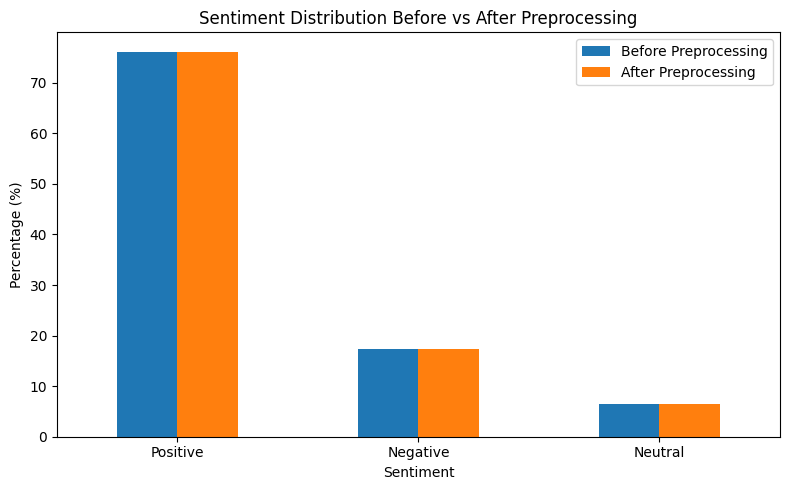

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Original distribution before text preprocessing
original_dist = pd.Series({
    "Positive": 76.16,
    "Negative": 17.32,
    "Neutral": 6.52
})

# Current distribution after preprocessing
current_dist = (
    df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
)

# Put them in the same order
comparison = pd.DataFrame({
    "Before Preprocessing": original_dist,
    "After Preprocessing": current_dist
}).loc[["Positive", "Negative", "Neutral"]]

print(comparison.round(2))

# Plot
comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sentiment Distribution Before vs After Preprocessing")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

            count   mean  median    std  min   max
Sentiment                                         
Negative    34636  26.16    16.0  35.23    1  1109
Neutral     13019  30.59    17.0  47.98    1  1880
Positive   151992  19.58    10.0  34.11    1  1624


<Figure size 900x600 with 0 Axes>

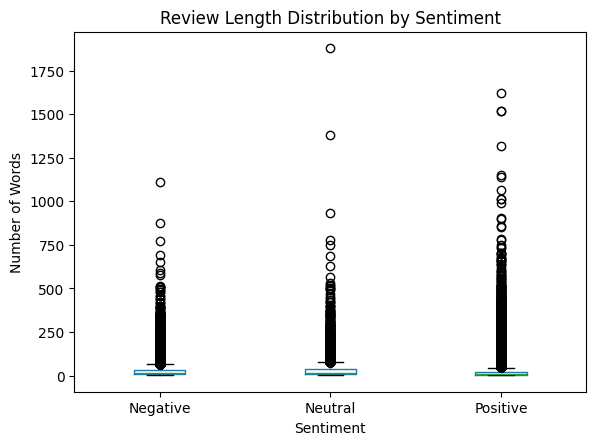

In [67]:
import matplotlib.pyplot as plt

# Summary statistics by sentiment
length_summary = (
    df.groupby("Sentiment")["Processed_Word_Count"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .loc[["Negative", "Neutral", "Positive"]]
)

print(length_summary.round(2))


# Boxplot
plt.figure(figsize=(9, 6))

df.boxplot(
    column="Processed_Word_Count",
    by="Sentiment",
    grid=False
)

plt.title("Review Length Distribution by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.show()

<Figure size 900x600 with 0 Axes>

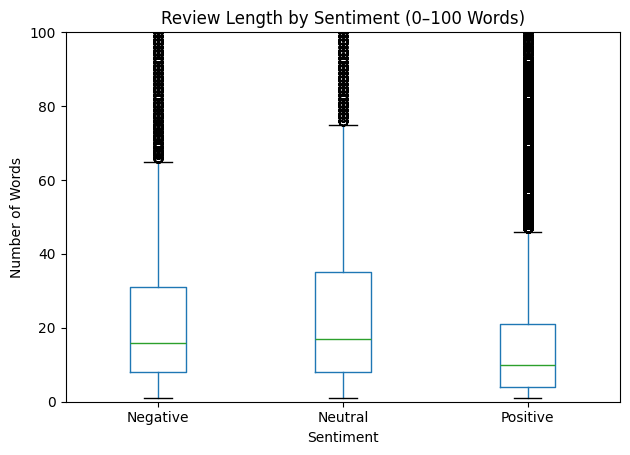

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

df.boxplot(
    column="Processed_Word_Count",
    by="Sentiment",
    grid=False
)

plt.ylim(0, 100)

plt.title("Review Length by Sentiment (0–100 Words)")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

In [69]:
#Most Frequent Words

from collections import Counter

word_counts = Counter(
    word
    for tokens in df["Tokens_Lemma"]
    for word in tokens
)

top_words = word_counts.most_common(30)

top_words

[('not', 118938),
 ('great', 55604),
 ('work', 52960),
 ('good', 38159),
 ('use', 34277),
 ('just', 31378),
 ('like', 30648),
 ('product', 28777),
 ('no', 27173),
 ('sound', 24448),
 ('quality', 24243),
 ('time', 22935),
 ('easy', 22358),
 ('love', 22312),
 ('doe', 21883),
 ('case', 21500),
 ('price', 19509),
 ('camera', 18815),
 ('did', 18670),
 ('really', 17499),
 ('bought', 16881),
 ('fit', 16795),
 ('cable', 16710),
 ('im', 16079),
 ('battery', 15796),
 ('need', 14709),
 ('nice', 13965),
 ('little', 13307),
 ('tv', 13280),
 ('used', 13203)]

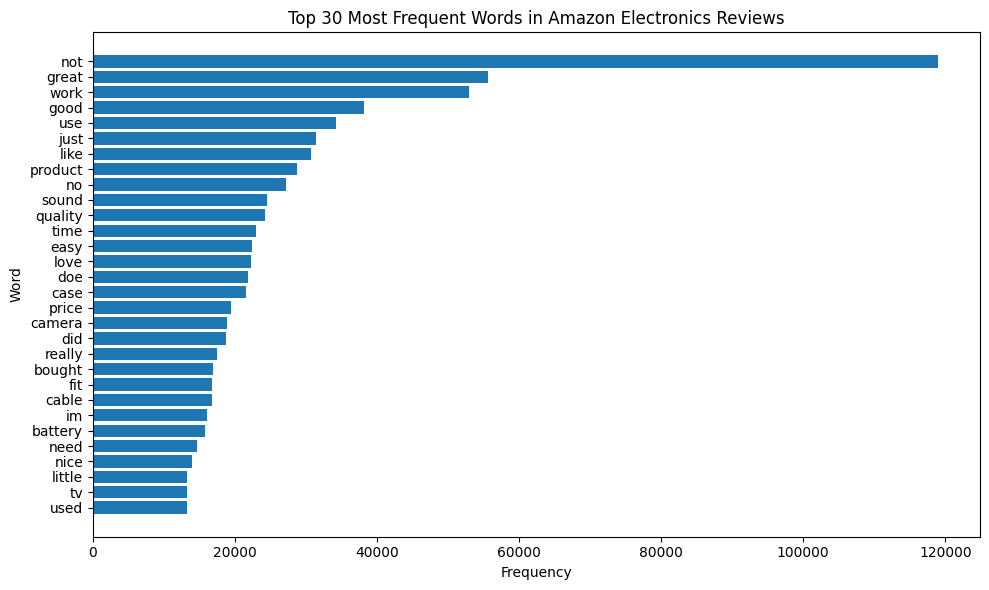

In [70]:
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 30 Most Frequent Words in Amazon Electronics Reviews")

plt.tight_layout()
plt.show()

In [71]:
df[df["Sentiment"] == "Positive"]["Tokens_Lemma"]

0                           [3td, kindle, love, able, book]
3         [like, lens, bulbous, element, using, filter, ...
4                                         [work, perfectly]
5                             [great, item, fast, shipping]
6                         [looking, work, keyboard, bought]
                                ...                        
199994    [great, thing, adjust, height, really, easy, t...
199996    [laptop, great, play, just, steam, account, hi...
199997    [amplifier, exactly, looking, small, simple, p...
199998    [high, school, son, impressed, tool, msword, f...
199999                          [like, work, fast, durable]
Name: Tokens_Lemma, Length: 151992, dtype: object

In [72]:
df[df["Sentiment"] == "Negative"]["Tokens_Lemma"]

1         [build, quality, fine, window, 11, came, runni...
2             [not, connect, computer, tech, support, help]
7         [advertised, certified, refurbished, instead, ...
30                                       [sound, not, good]
34        [sound, really, good, left, ear, bud, went, 5,...
                                ...                        
199975    [device, andor, software, incredibly, unreliab...
199979    [updating, 2, star, 1, star, reaching, pop, de...
199992                         [dead, arrival, refund, say]
199993    [disappointing, poor, quality, picture, differ...
199995    [sound, good, return, not, stay, ear, hadnt, e...
Name: Tokens_Lemma, Length: 34636, dtype: object

In [73]:
df[df["Sentiment"] == "Neutral"]["Tokens_Lemma"]

44        [purchase, camera, 8, year, son, difficult, br...
49        [bought, son, threw, remote, tub, worked, grea...
51        [fantastic, earbuds, 2, year, just, recently, ...
70        [not, installed, caught, guard, 12, piece, unn...
73        [thing, bother, constantly, having, fiddle, co...
                                ...                        
199907    [great, sound, annoying, constant, flashing, b...
199945    [nice, limited, range, touchpad, not, sensitiv...
199976    [husband, radio, powerful, speakerso, wasnt, s...
199977            [echo, dot, 3, month, old, stop, working]
199984    [let, say, came, wrong, driver, download, driv...
Name: Tokens_Lemma, Length: 13019, dtype: object

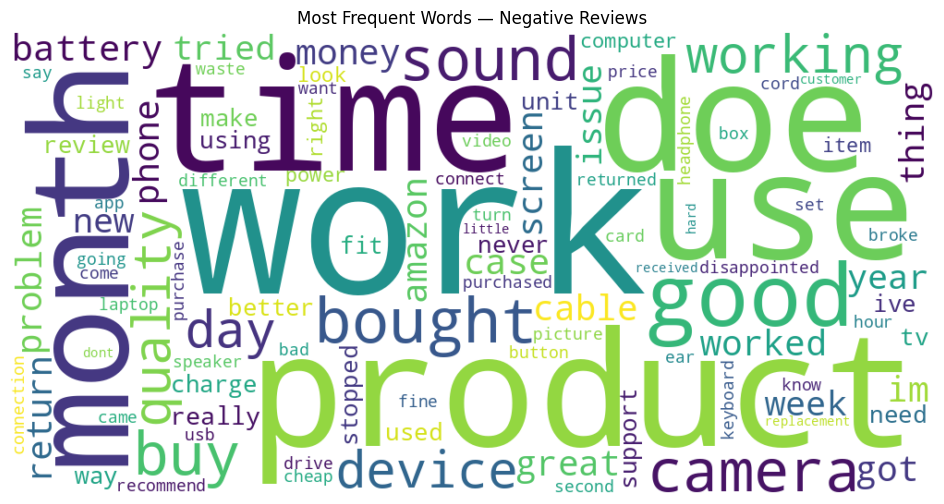

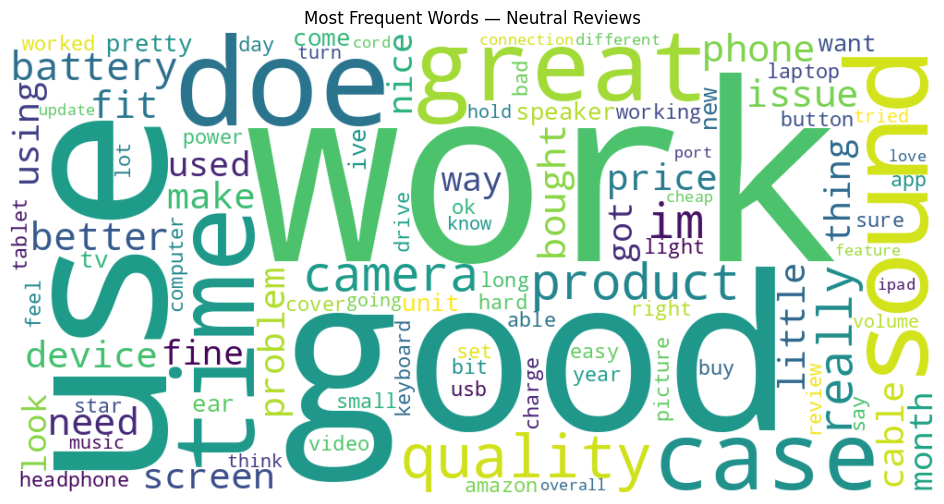

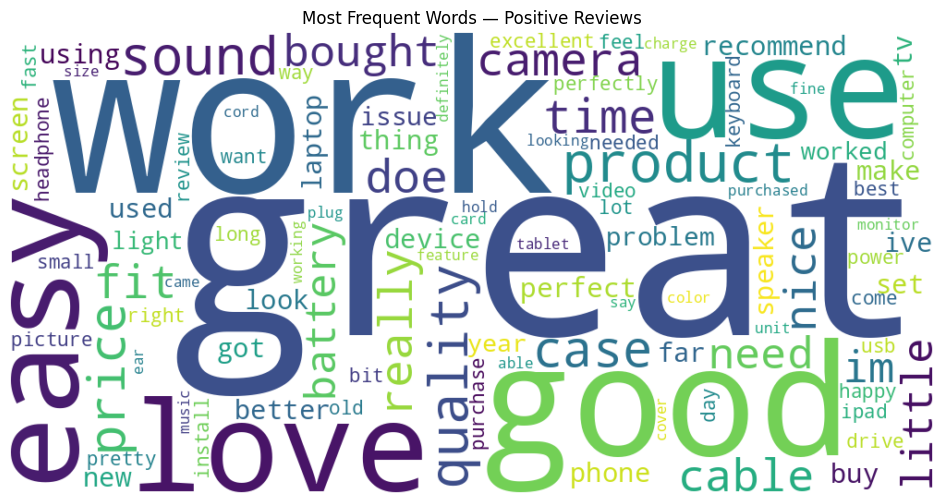

In [74]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sentiments = ["Negative", "Neutral", "Positive"]

for sentiment in sentiments:

    # Get all lemmatized tokens for this sentiment
    words = [
        word
        for tokens in df.loc[df["Sentiment"] == sentiment, "Tokens_Lemma"]
        for word in tokens
    ]

    # Combine words into one text
    text = " ".join(words)

    # Create word cloud
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100,
        collocations=False
    ).generate(text)

    # Plot separately
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Most Frequent Words — {sentiment} Reviews")
    plt.show()

In [75]:
from collections import Counter

for sentiment in ["Negative", "Neutral", "Positive"]:

    words = [
        word
        for tokens in df.loc[df["Sentiment"] == sentiment, "Tokens_Lemma"]
        for word in tokens
    ]

    top_words = Counter(words).most_common(20)

    print(f"\n{'='*15} {sentiment.upper()} {'='*15}")
    
    for word, count in top_words:
        print(f"{word:<20} {count}")


=============== NEGATIVE ===============
not                  40036
work                 10552
no                   7285
just                 6905
product              6664
time                 6459
did                  6363
doe                  6220
use                  5810
month                4899
like                 4876
good                 4229
bought               4138
sound                3834
buy                  3768
camera               3741
working              3642
quality              3641
2                    3569
day                  3454

=============== NEUTRAL ===============
not                  15059
work                 4221
just                 3158
good                 3129
like                 3063
use                  3008
doe                  2780
no                   2351
sound                2346
time                 2326
great                2251
case                 2038
did                  1982
quality              1860
product              1735
came

In [76]:
#bigram analysis

from collections import Counter

for sentiment in ["Negative", "Neutral", "Positive"]:

    bigram_counts = Counter()

    for tokens in df.loc[df["Sentiment"] == sentiment, "Tokens_Lemma"]:
        bigrams = zip(tokens, tokens[1:])
        bigram_counts.update(bigrams)

    print(f"\n{'='*15} {sentiment.upper()} {'='*15}")

    for (w1, w2), count in bigram_counts.most_common(20):
        print(f"{w1} {w2:<25} {count}")


=============== NEGATIVE ===============
doe not                       5195
did not                       4892
not work                      3928
stopped working                   1616
not buy                       1459
waste money                     1234
not recommend                 1111
not fit                       966
sound quality                   782
not worth                     750
not good                      706
customer service                   678
no longer                    634
not use                       526
not charge                    521
not sure                      519
not know                      495
not waste                     474
im not                       456
battery life                      452

=============== NEUTRAL ===============
doe not                       1866
did not                       1409
not work                      718
sound quality                   481
not sure                      372
battery life                      304
wor

In [77]:
#trigram analysis

from collections import Counter

for sentiment in ["Negative", "Neutral", "Positive"]:

    trigram_counts = Counter()

    for tokens in df.loc[df["Sentiment"] == sentiment, "Tokens_Lemma"]:
        trigrams = zip(tokens, tokens[1:], tokens[2:])
        trigram_counts.update(trigrams)

    print(f"\n{'='*15} {sentiment.upper()} {'='*15}")

    for (w1, w2, w3), count in trigram_counts.most_common(20):
        print(f"{w1} {w2} {w3:<25} {count}")


=============== NEGATIVE ===============
doe not work                      1506
did not work                      1475
doe not fit                       438
not waste money                     354
did not fit                       318
not work not                       191
not recommend product                   187
not worth money                     154
just stopped working                   153
product doe not                       152
im not sure                      147
dont waste money                     144
product did not                       141
waste time money                     139
did not like                      125
did not come                      116
doe not stay                      113
did not want                      107
not buy product                   105
not hold charge                    103

=============== NEUTRAL ===============
doe not work                      278
did not work                      205
im not sure                      108
doe not fit 

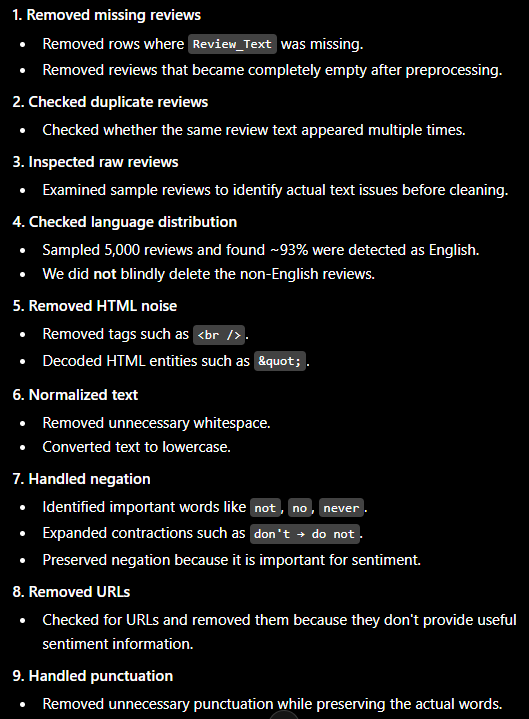

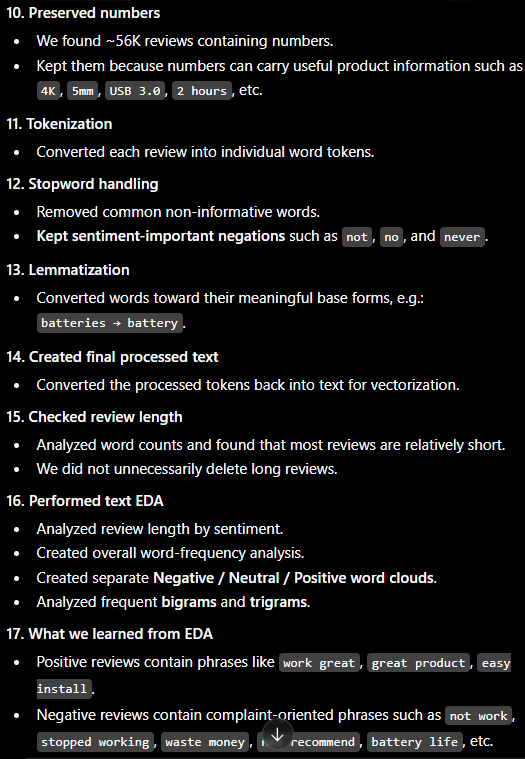

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["Processed_Text"],
    df["Sentiment"],
    test_size=0.20,
    random_state=42,
    stratify=df["Sentiment"]
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 159717
Testing samples: 39930


In [80]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['Negative' 'Neutral' 'Positive']


In [81]:
import pandas as pd

print("Train:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTest:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().mul(100).round(2))

Train:
0    17.35
1     6.52
2    76.13
Name: proportion, dtype: float64

Test:
0    17.35
1     6.52
2    76.13
Name: proportion, dtype: float64


***Feature Engineering***

In [82]:
#BoW -> Bag of Words model

from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer_full = CountVectorizer(
    ngram_range=(1, 1)
)

X_train_bow_full = bow_vectorizer_full.fit_transform(X_train)

print("BoW shape:", X_train_bow_full.shape)
print("Full vocabulary size:", len(bow_vectorizer_full.vocabulary_))

BoW shape: (159717, 80769)
Full vocabulary size: 80769


In [83]:
from collections import Counter

word_frequency = Counter(
    word
    for text in X_train
    for word in text.split()
)

pd.Series(word_frequency).describe()

count    82166.000000
mean        41.625575
std        588.154682
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max      94935.000000
dtype: float64

In [84]:
thresholds = [2, 3, 5, 10, 20]

for threshold in thresholds:
    count = sum(
        1 for freq in word_frequency.values()
        if freq >= threshold
    )
    print(f"min frequency >= {threshold}: {count} words")

min frequency >= 2: 32406 words
min frequency >= 3: 23464 words
min frequency >= 5: 16724 words
min frequency >= 10: 11090 words
min frequency >= 20: 7526 words


In [85]:
bow_vectorizer = CountVectorizer(
    min_df=5,
    max_features=20000,
    ngram_range=(1, 1)
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("Training shape:", X_train_bow.shape)
print("Testing shape:", X_test_bow.shape)
print("Vocabulary size:", len(bow_vectorizer.vocabulary_))

Training shape: (159717, 15632)
Testing shape: (39930, 15632)
Vocabulary size: 15632


In [87]:
X_train_bow[1]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (1, 15632)>

In [88]:
bow_vectorizer.get_feature_names_out()[:50]

array(['00', '0000', '001', '01', '010', '02', '025', '03', '04', '05',
       '06', '07', '08', '09', '10', '100', '1000', '10000', '100000',
       '1000mbps', '1000w', '1000x', '100150', '100200', '100400',
       '100400mm', '100fps', '100ft', '100gb', '100hz', '100m', '100mb',
       '100mbps', '100mbs', '100mm', '100w', '100x', '101', '1010',
       '10100', '101001000', '1011', '1012', '1015', '102', '1020',
       '1024', '1025', '103', '1030'], dtype=object)

In [89]:
print("Review:")
print(X_train.iloc[0])

print("\nBoW vector:")
print(X_train_bow[0].toarray())

Review:
good cable work

BoW vector:
[[0 0 0 ... 0 0 0]]


In [90]:
row = X_train_bow[0]

feature_names = bow_vectorizer.get_feature_names_out()

nonzero_indices = row.nonzero()[1]

bow_words = {
    feature_names[i]: row[0, i]
    for i in nonzero_indices
}

bow_words

{'good': np.int64(1), 'cable': np.int64(1), 'work': np.int64(1)}

In [91]:
#Just a baseline model #LogReg + BOW model

from sklearn.linear_model import LogisticRegression

bow_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

bow_lr.fit(X_train_bow, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_bow = bow_lr.predict(X_test_bow)

# Overall metrics
accuracy = accuracy_score(y_test, y_pred_bow)

precision_macro = precision_score(
    y_test, y_pred_bow, average="macro"
)

recall_macro = recall_score(
    y_test, y_pred_bow, average="macro"
)

f1_macro = f1_score(
    y_test, y_pred_bow, average="macro"
)

precision_weighted = precision_score(
    y_test, y_pred_bow, average="weighted"
)

recall_weighted = recall_score(
    y_test, y_pred_bow, average="weighted"
)

f1_weighted = f1_score(
    y_test, y_pred_bow, average="weighted"
)

print("===== BoW + Logistic Regression =====")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Macro Precision   : {precision_macro:.4f}")
print(f"Macro Recall      : {recall_macro:.4f}")
print(f"Macro F1          : {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall   : {recall_weighted:.4f}")
print(f"Weighted F1      : {f1_weighted:.4f}")

print("\n===== Classification Report =====")
print(
    classification_report(
        y_test,
        y_pred_bow,
        target_names=label_encoder.classes_
    )
)

===== BoW + Logistic Regression =====
Accuracy          : 0.8012
Macro Precision   : 0.6072
Macro Recall      : 0.6555
Macro F1          : 0.6195
Weighted Precision: 0.8524
Weighted Recall   : 0.8012
Weighted F1      : 0.8227

===== Classification Report =====
              precision    recall  f1-score   support

    Negative       0.67      0.72      0.69      6927
     Neutral       0.20      0.40      0.26      2604
    Positive       0.95      0.86      0.90     30399

    accuracy                           0.80     39930
   macro avg       0.61      0.66      0.62     39930
weighted avg       0.85      0.80      0.82     39930



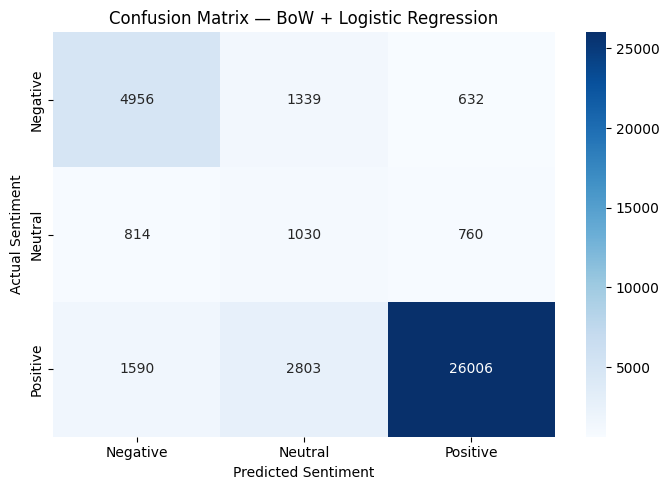

In [95]:
cm = confusion_matrix(y_test, y_pred_bow)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix — BoW + Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [96]:
#TF-IDF process

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_features=20000,
    ngram_range=(1, 1),
    sublinear_tf=True
)

# Fit ONLY on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data using the same fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

Training TF-IDF shape: (159717, 15632)
Testing TF-IDF shape: (39930, 15632)
Vocabulary size: 15632


In [97]:
#TF-IDF + LogReg

from sklearn.linear_model import LogisticRegression

tfidf_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

tfidf_lr.fit(X_train_tfidf, y_train)

y_pred_tfidf = tfidf_lr.predict(X_test_tfidf)

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("===== TF-IDF + Logistic Regression =====")

print(f"Accuracy       : {accuracy_score(y_test, y_pred_tfidf):.4f}")
print(f"Macro Precision: {precision_score(y_test, y_pred_tfidf, average='macro'):.4f}")
print(f"Macro Recall   : {recall_score(y_test, y_pred_tfidf, average='macro'):.4f}")
print(f"Macro F1       : {f1_score(y_test, y_pred_tfidf, average='macro'):.4f}")

print("\n===== Classification Report =====")
print(
    classification_report(
        y_test,
        y_pred_tfidf,
        target_names=label_encoder.classes_
    )
)

===== TF-IDF + Logistic Regression =====
Accuracy       : 0.7868
Macro Precision: 0.6154
Macro Recall   : 0.6837
Macro F1       : 0.6260

===== Classification Report =====
              precision    recall  f1-score   support

    Negative       0.68      0.73      0.70      6927
     Neutral       0.20      0.50      0.28      2604
    Positive       0.96      0.83      0.89     30399

    accuracy                           0.79     39930
   macro avg       0.62      0.68      0.63     39930
weighted avg       0.87      0.79      0.82     39930



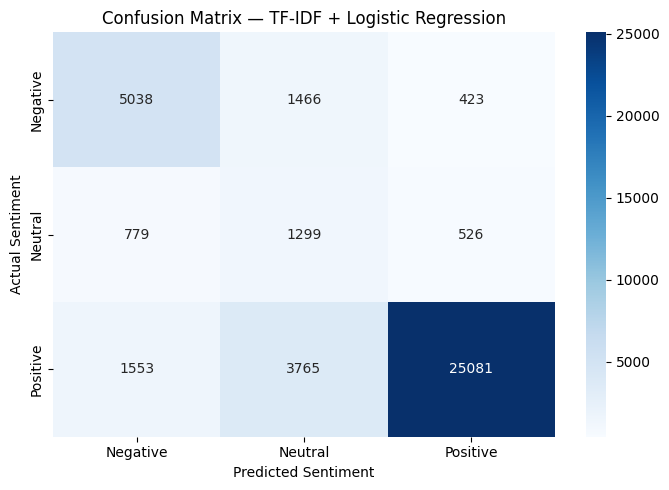

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [100]:
#TF_IDF Unigram + Bigram

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bigram_vectorizer = TfidfVectorizer(
    min_df=5,
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# Fit ONLY on training data
X_train_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(X_train)

# Transform test using the SAME vocabulary
X_test_tfidf_bigram = tfidf_bigram_vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf_bigram.shape)
print("Testing shape:", X_test_tfidf_bigram.shape)
print(
    "Vocabulary size:",
    len(tfidf_bigram_vectorizer.vocabulary_)
)

Training shape: (159717, 30000)
Testing shape: (39930, 30000)
Vocabulary size: 30000


In [101]:
tfidf_bigram_vectorizer.get_feature_names_out()[:100]

array(['04', '05', '08', '10', '10 10', '10 12', '10 15', '10 buck',
       '10 computer', '10 day', '10 degree', '10 device', '10 dollar',
       '10 foot', '10 ft', '10 great', '10 hour', '10 inch', '10 just',
       '10 laptop', '10 min', '10 minute', '10 month', '10 no', '10 not',
       '10 pc', '10 plus', '10 pro', '10 second', '10 star', '10 tablet',
       '10 time', '10 year', '10 yr', '100', '100 buck', '100 dollar',
       '100 foot', '100 ft', '100 hour', '100 mbps', '100 not',
       '100 recommend', '100 recommended', '100 satisfied', '100 time',
       '100 watt', '100 worth', '1000', '1000 watt', '10000', '100ft',
       '100mbps', '100mbs', '100mm', '100w', '101', '1010', '1010 buy',
       '1010 recommend', '10100', '1012', '1015', '1015 minute', '102',
       '1020', '104', '105', '1060', '1070', '108', '1080', '1080i',
       '1080p', '1080p hd', '1080p monitor', '1080p tv', '1080p video',
       '109', '10ft', '10gb', '10gbps', '10mm', '10th', '10x', '11',
       '

In [102]:
#TF_IDF Unigram + Bigram + LogReg

from sklearn.linear_model import LogisticRegression

tfidf_bigram_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

tfidf_bigram_lr.fit(
    X_train_tfidf_bigram,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [104]:
y_pred_tfidf_bigram = tfidf_bigram_lr.predict(
    X_test_tfidf_bigram
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("===== TF-IDF Unigram + Bigram + Logistic Regression =====")

print(
    f"Accuracy       : "
    f"{accuracy_score(y_test, y_pred_tfidf_bigram):.4f}"
)

print(
    f"Macro Precision: "
    f"{precision_score(y_test, y_pred_tfidf_bigram, average='macro'):.4f}"
)

print(
    f"Macro Recall   : "
    f"{recall_score(y_test, y_pred_tfidf_bigram, average='macro'):.4f}"
)

print(
    f"Macro F1       : "
    f"{f1_score(y_test, y_pred_tfidf_bigram, average='macro'):.4f}"
)

print("\n===== Classification Report =====")

print(
    classification_report(
        y_test,
        y_pred_tfidf_bigram,
        target_names=label_encoder.classes_
    )
)

===== TF-IDF Unigram + Bigram + Logistic Regression =====
Accuracy       : 0.8141
Macro Precision: 0.6326
Macro Recall   : 0.6942
Macro F1       : 0.6469

===== Classification Report =====
              precision    recall  f1-score   support

    Negative       0.71      0.75      0.73      6927
     Neutral       0.22      0.47      0.30      2604
    Positive       0.96      0.86      0.91     30399

    accuracy                           0.81     39930
   macro avg       0.63      0.69      0.65     39930
weighted avg       0.87      0.81      0.84     39930



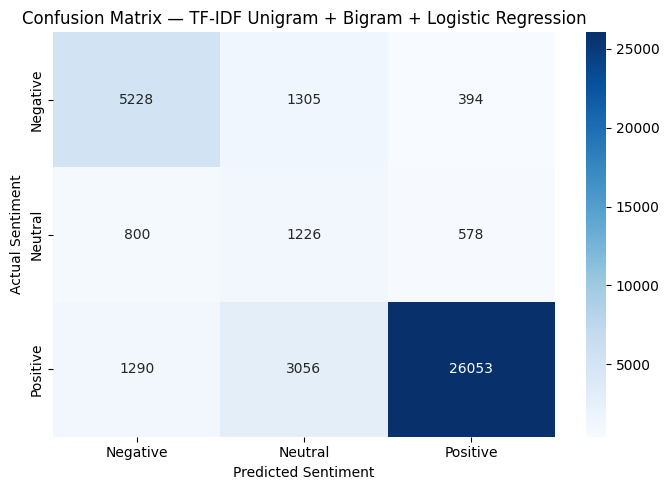

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_tfidf_bigram = confusion_matrix(
    y_test,
    y_pred_tfidf_bigram
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tfidf_bigram,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Confusion Matrix — TF-IDF Unigram + Bigram + Logistic Regression"
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()
plt.show()

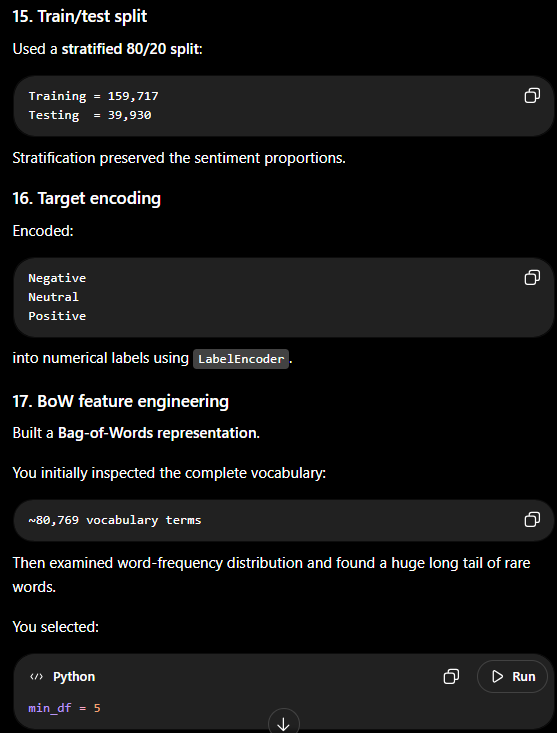

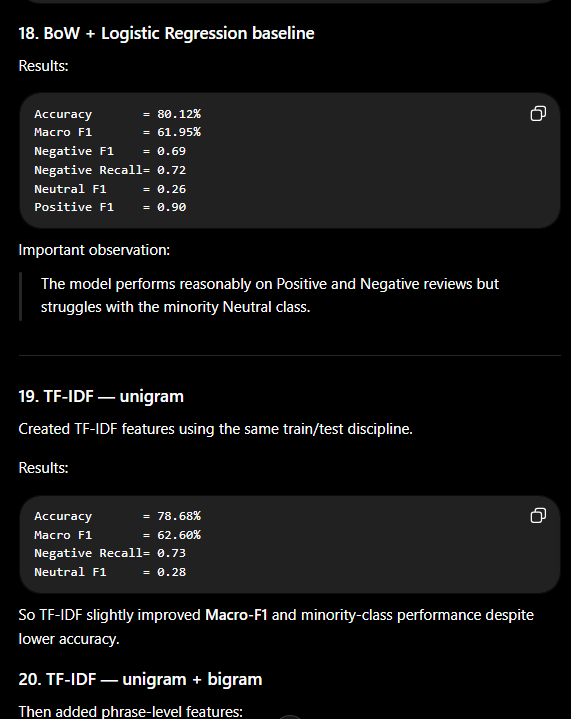

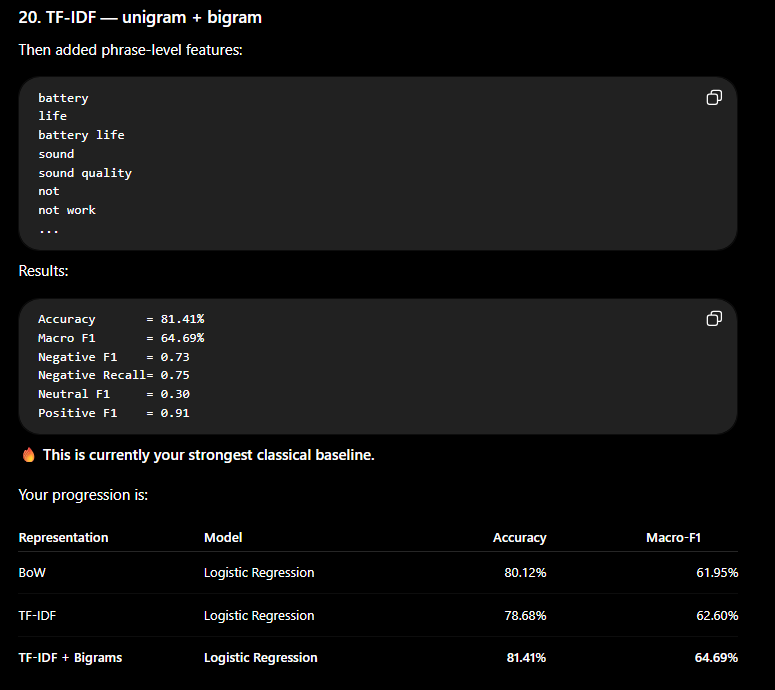